In [22]:

import numpy as np
from src.utils import load_data

# LOADING 

training_dir = r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training"
testing_dir_no_tumor = r"C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Testing\no_tumor"

classes = {
    "glioma_tumor": 0,
    "meningioma_tumor": 1,
    "no_tumor": 2,
    "pituitary_tumor": 3,
}
inverted_classes = {0: "Glioma", 1: "Meningioma", 2: "No Tumor", 3: "Pituitary"}


X, Y = load_data(training_dir, classes)

# PROCESSING 

# turn images into numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Shapes: ", X.shape, Y.shape)


C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training\glioma_tumor
C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training\meningioma_tumor
C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training\no_tumor
C:\Users\rqg886\Desktop\brain-tumor-detection\data\raw\Training\pituitary_tumor
Shapes:  (2870, 200, 200) (2870,)


In [23]:
# make sure to match original model's preprocessing function
from keras.applications.resnet50 import preprocess_input 
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_gen = ImageDataGenerator(
        validation_split = 0.2, 
        preprocessing_function = preprocess_input)
train_flow = train_gen.flow_from_directory("data/raw/Training", 
                                           target_size =(256, 256), 
                                           batch_size = 32, 
                                           subset ="training")

valid_flow = train_gen.flow_from_directory("data/raw/Training", 
                                           target_size =(256, 256), 
                                           batch_size = 32, 
                                           subset ="validation",
                                           shuffle = False) # aka validation

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


In [24]:
test_gen = ImageDataGenerator(
        preprocessing_function = preprocess_input)
test_flow = test_gen.flow_from_directory("data/raw/Testing", 
                                         target_size =(256, 256), 
                                         batch_size = 32,
                                         shuffle = False)

Found 394 images belonging to 4 classes.


In [25]:
from keras.applications.resnet50 import ResNet50
from keras.layers import GlobalAveragePooling2D, Dense
from keras.layers import BatchNormalization, Dropout
from keras.models import Model

# by default, the loaded model will include the original CNN 
#classifier designed for the ImageNet dataset
# since we want to reuse this model for a different problem,
# we need to omit the original fully connected layers, and 
# replace them with our own setting include_top = False will
# load the model without the fully connected layer

# load resnet model, with pretrained imagenet weights.
res = ResNet50(weights ='imagenet', include_top = False, 
               input_shape =(256, 256, 3))

# freeze the entire ResNet backbone
# keeps the original weights
res.trainable = False

In [26]:
x = res.output

In [27]:
x.shape

(None, 8, 8, 2048)

In [28]:
x[0].shape

(8, 8, 2048)

In [29]:
x = GlobalAveragePooling2D()(x)

In [30]:
x[0].shape

(2048,)

In [31]:
x = BatchNormalization()(x)

In [32]:
# neural net dropout to reduce overfitting
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x) # why 512?
x = BatchNormalization()(x) # why normalization again?
x = Dropout(0.5)(x)

In [33]:
# output classification later --> 4 classes = 4 output neurons
x = Dense(4, activation='softmax')(x)
model = Model(res.input, x)

In [34]:
model.compile(optimizer='Adam',
              loss = 'categorical_crossentropy', # why this? review losses
              metrics = ['accuracy'])

# model.summary()

In [35]:
# train the model 

model.fit(train_flow, epochs = 7, validation_data = valid_flow)

Epoch 1/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 73s 973ms/step - accuracy: 0.7475 - loss: 0.8749 - val_accuracy: 0.6963 - val_loss: 0.8821
Epoch 2/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8603 - loss: 0.4127 - val_accuracy: 0.7976 - val_loss: 0.5867
Epoch 3/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8968 - loss: 0.2851 - val_accuracy: 0.7958 - val_loss: 0.5943
Epoch 4/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 964ms/step - accuracy: 0.8999 - loss: 0.2821 - val_accuracy: 0.8098 - val_loss: 0.5878
Epoch 5/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 936ms/step - accuracy: 0.9177 - loss: 0.2074 - val_accuracy: 0.8150 - val_loss: 0.5903
Epoch 6/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 935ms/step - accuracy: 0.9277 - loss: 0.1978 - val_accuracy: 0.8482 - val_loss: 0.5788
Epoch 7/7
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 954ms/step - accuracy: 0.9404 - loss: 0.1609 - val_accuracy: 0.8325 - val_loss: 0.6290


In [36]:
result = model.evaluate(test_flow)

print('The model achieved a loss of %.2f and,'
      'accuracy of %.2f%%.' % (result[0], result[1]*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 729ms/step - accuracy: 0.7005 - loss: 1.8309
The model achieved a loss of 1.83 and,accuracy of 70.05%.


In [37]:
#getpredictions

In [38]:
import numpy as np

probs = model.predict(test_flow)              # shape: (n_samples, 4)
y_pred = np.argmax(probs, axis=1)             # predicted class index per image
y_true = test_flow.classes                    # true class index per image
class_names = list(test_flow.class_indices.keys())   # ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 816ms/step


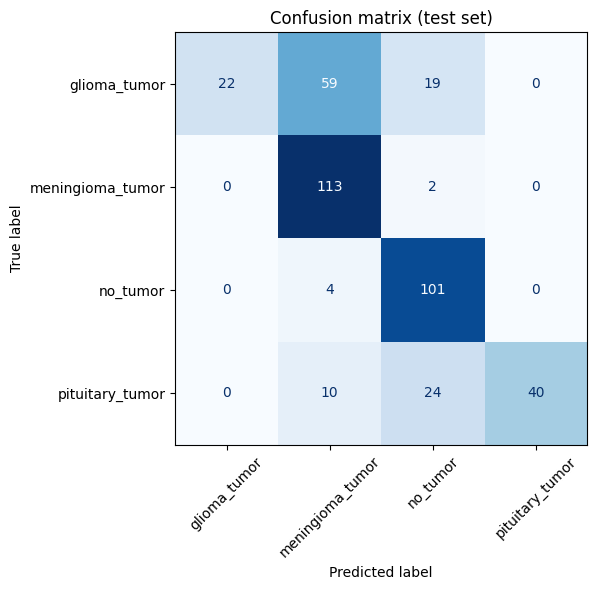

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()


In [40]:
def show_examples(true_cls, pred_cls, n=6):
    """Show n images where true class == true_cls and predicted == pred_cls."""
    idxs = np.where((y_true == true_cls) & (y_pred == pred_cls))[0]
    if len(idxs) == 0:
        print(f"No samples: true={class_names[true_cls]}, predicted={class_names[pred_cls]}")
        return
    idxs = idxs[:n]

    fig, axes = plt.subplots(1, len(idxs), figsize=(3*len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]

    filenames = test_flow.filenames
    for ax, i in zip(axes, idxs):
        img_path = os.path.join(test_flow.directory, filenames[i])
        img = plt.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"conf={probs[i, pred_cls]:.2f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(f"true: {class_names[true_cls]}  →  predicted: {class_names[pred_cls]}", y=1.05)
    plt.tight_layout(); plt.show()


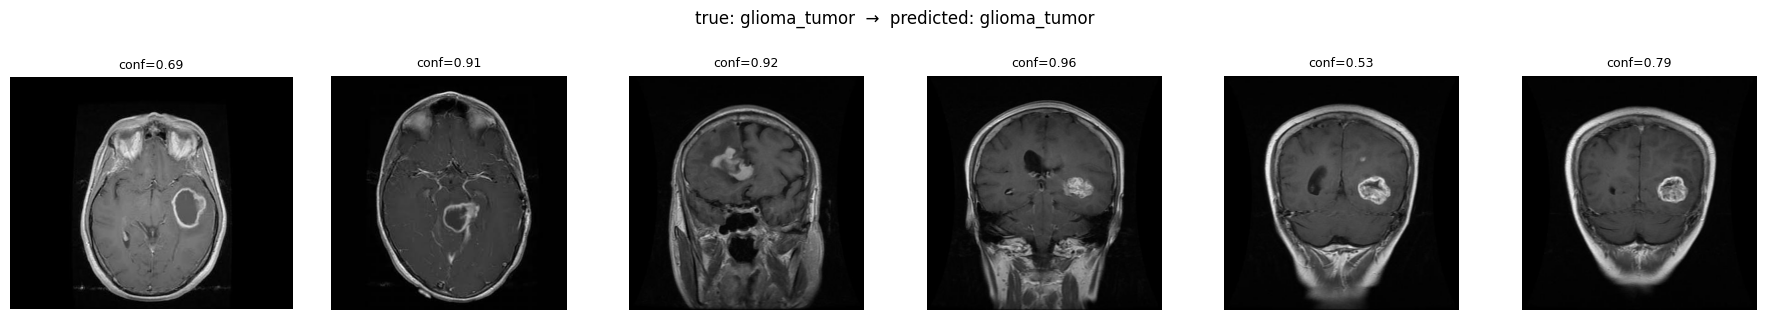

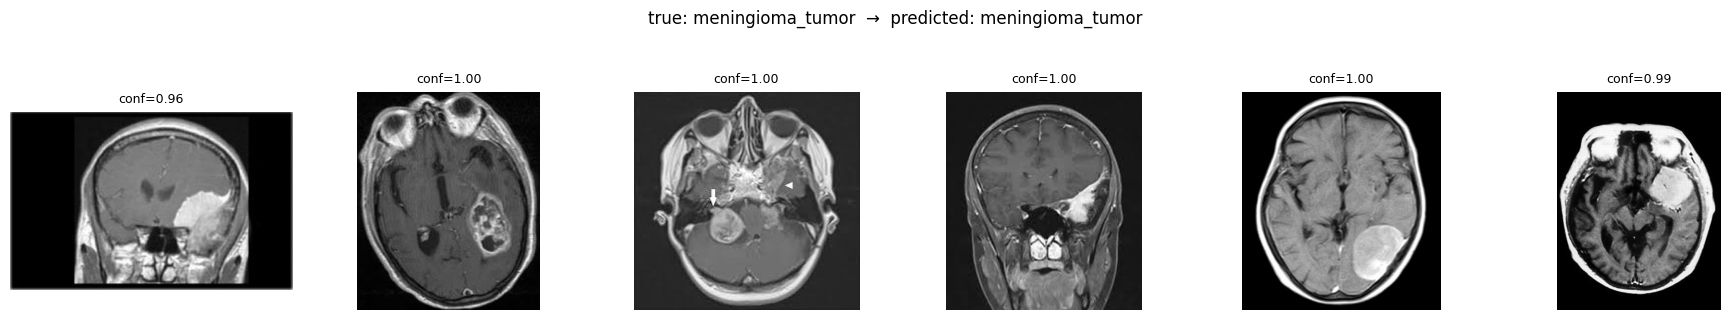

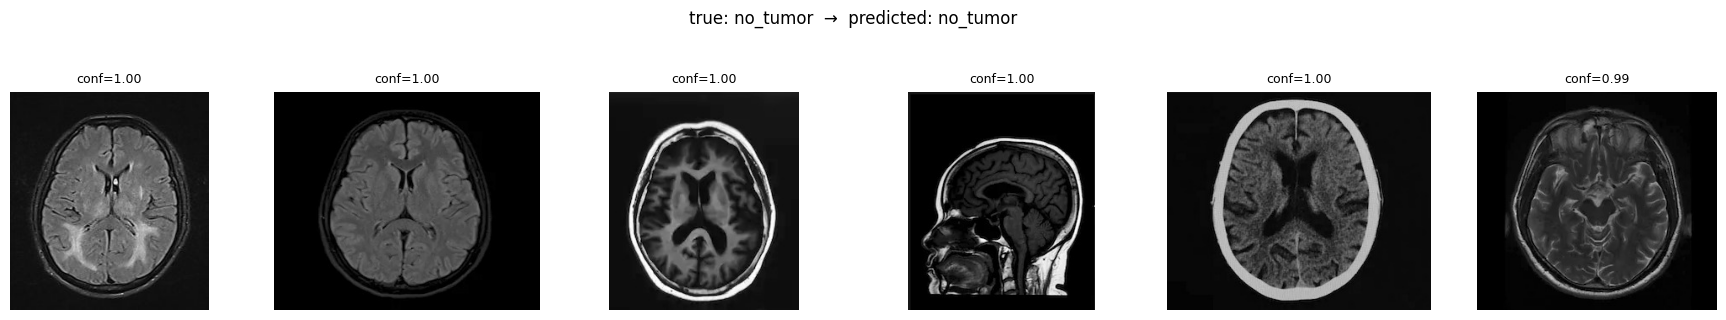

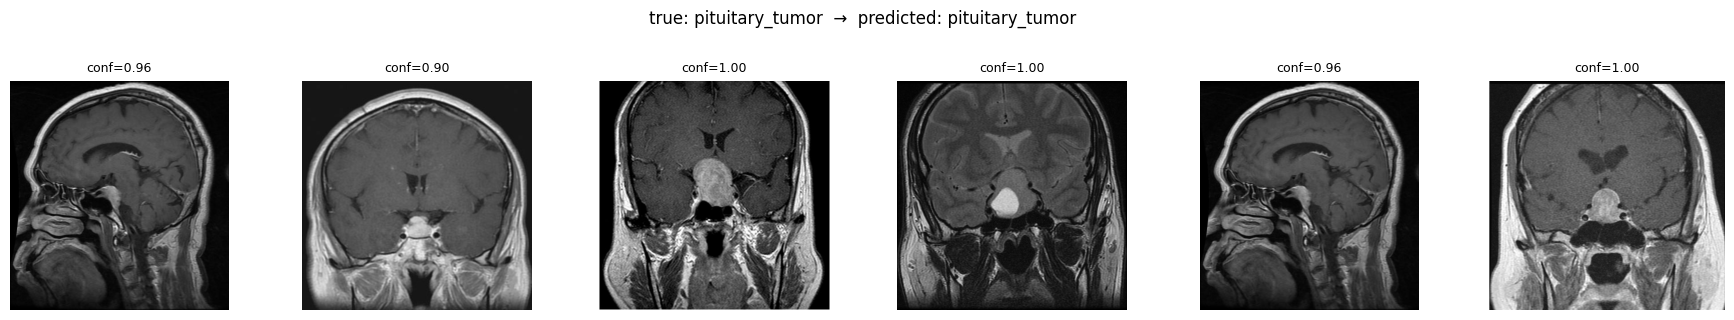

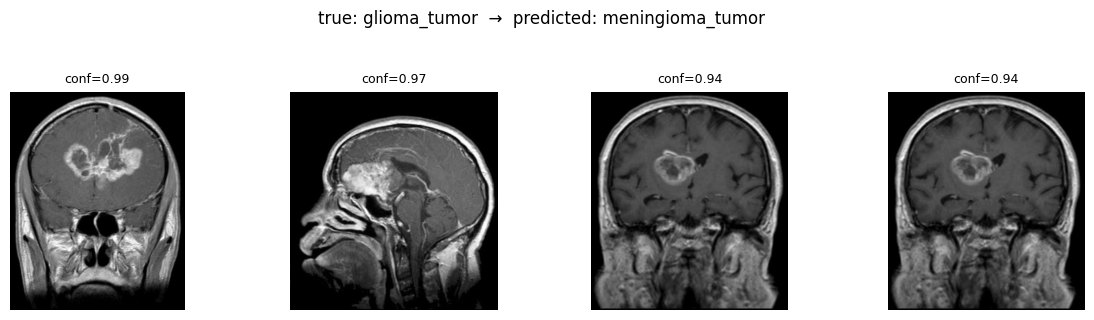

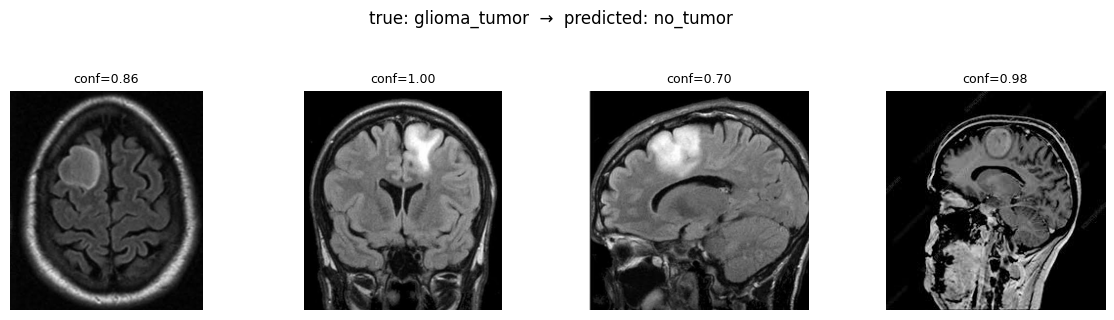

No samples: true=glioma_tumor, predicted=pituitary_tumor


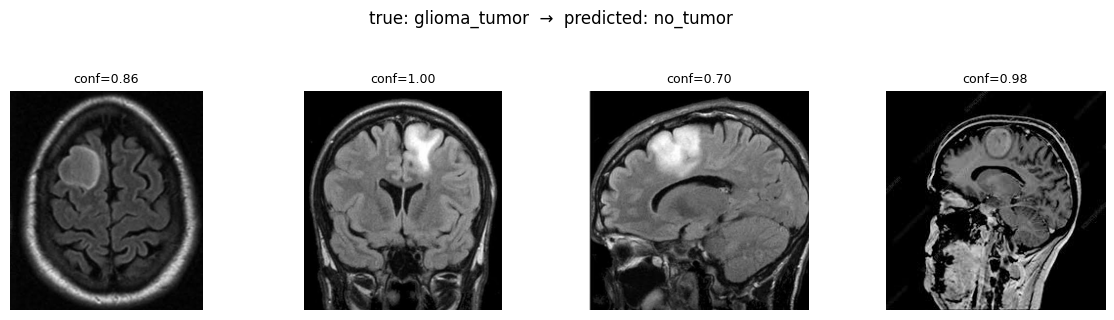

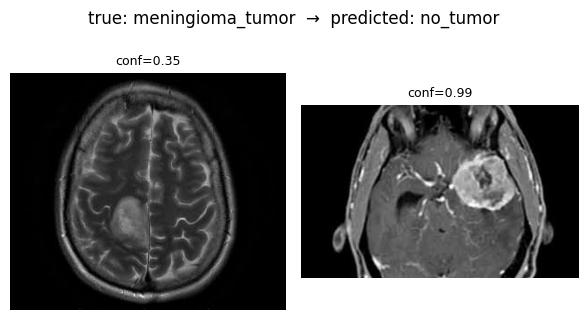

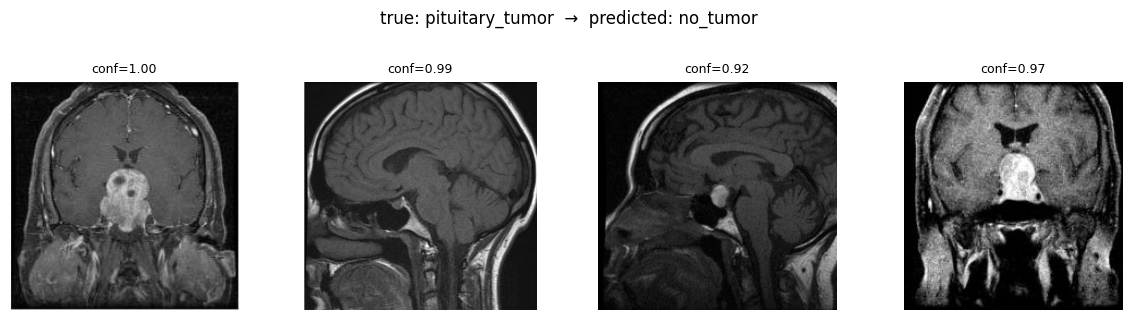

In [41]:
# Correct predictions (diagonal) — sanity check
for c in range(4):
    show_examples(true_cls=c, pred_cls=c, n=6)

# All mistakes for the "glioma" class (row 0, off-diagonal)
for pred in range(4):
    if pred != 0:
        show_examples(true_cls=0, pred_cls=pred, n=4)

# All false positives for "no_tumor" (column 2, off-diagonal) — these are the dangerous ones in a medical context
for true in range(4):
    if true != 2:
        show_examples(true_cls=true, pred_cls=2, n=4)


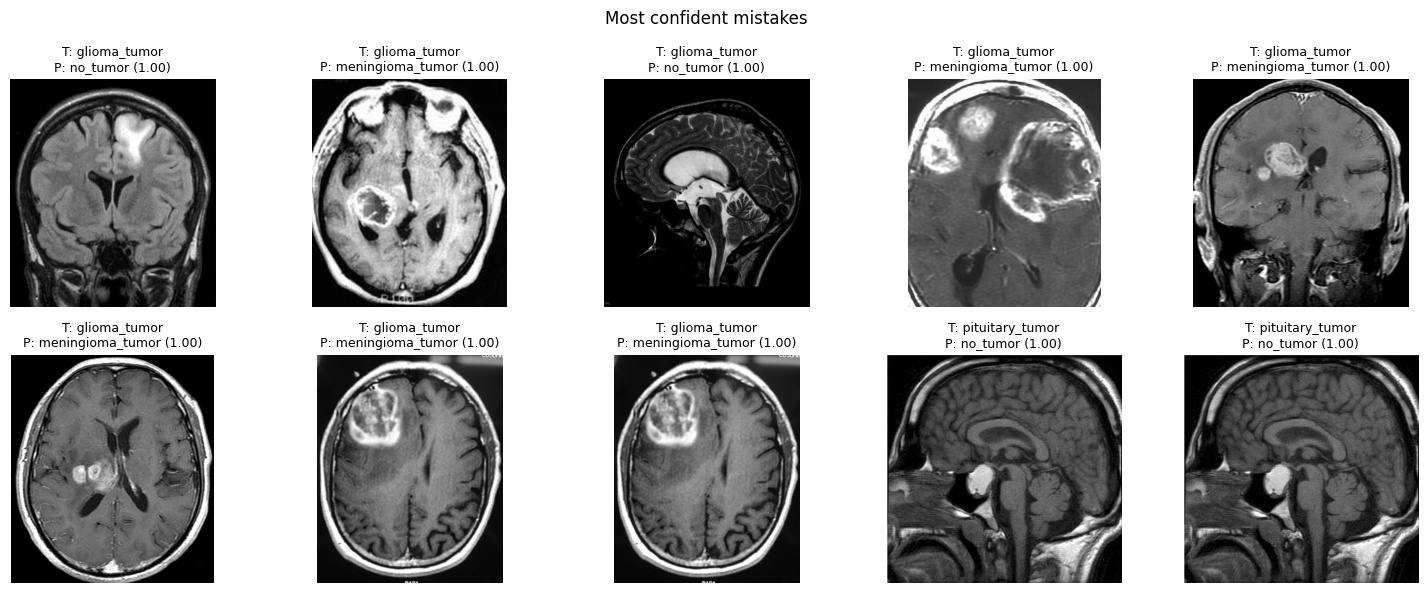

In [42]:
import os

wrong = np.where(y_pred != y_true)[0]
confidence_in_wrong_answer = probs[wrong, y_pred[wrong]]
top_wrong = wrong[np.argsort(-confidence_in_wrong_answer)][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, i in zip(axes.flat, top_wrong):
    img = plt.imread(os.path.join(test_flow.directory, test_flow.filenames[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {class_names[y_true[i]]}\nP: {class_names[y_pred[i]]} ({probs[i, y_pred[i]]:.2f})",
                 fontsize=9)
    ax.axis('off')
plt.suptitle("Most confident mistakes")
plt.tight_layout(); plt.show()
